<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/blob/main/MLFinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Risk of Poverty in CA

Aziza, Fong, Marcela

### **Primary Research Question**

Can demographic characteristics, employment conditions, education level, and health insurance coverage be used to accurately predict whether an individual in California falls below the poverty threshold?


### **Supporting Research Questions**

Education and Employment Effects on Poverty Risk:

How do education level, employment status, hours worked per week, and wage income influence an individual’s likelihood of falling below the poverty threshold?

Demographic and Access-to-Services Inequality:

How do age, marital status, citizenship status, and health insurance coverage contribute to differences in predicted poverty risk across individuals in California?

### **Why this topic?**

Poverty remains a critical social and economic issue in California, affecting millions of individuals and contributing to inequality in health, education, and economic opportunity. Identifying populations that are most vulnerable to poverty is essential for policymakers, nonprofits, and government agencies to design targeted interventions and allocate resources effectively.

This project leverages machine learning to predict poverty risk based on key factors such as education, employment conditions, demographic characteristics, and access to health insurance. These variables were chosen because they represent structural determinants of economic stability and are commonly used in policy analysis.

In addition to prediction, the project aims to identify the most influential factors driving poverty risk. This allows for actionable insights, helping decision-makers prioritize areas such as education access, employment quality, and healthcare coverage to reduce poverty at scale.

### **Literature Survey**



### Poverty Prediction Studies

| Authors / Study | Title | Dataset Used | Method | Key Findings |
|---|---|---|---|---|
| Rusnak (2012) | Logistic Regression Model in Poverty Analysis | Household survey data | Logistic Regression | Identified income, employment, and education as key determinants of poverty; showed logit models are effective for estimating poverty risk. |
| Peng et al. (2019) | Determinants of Poverty Across the Poverty Spectrum | Hong Kong Panel Survey | Logistic + Quantile Regression | Found that unemployment, low education, single status, and poor health significantly increase poverty risk. |
| Kim (2021) | Predicting Poverty Status in Costa Rican Households | Costa Rican household dataset | Random Forest, Gradient Boosting | Found that education is one of the strongest predictors of poverty; machine learning models outperform traditional approaches. |
| Chinyama (2022) | Predicting Household Poverty with Machine Learning | Malawi survey data | Logistic Regression, Boosting | Showed poverty can be predicted with high accuracy using fewer key features and emphasized feature importance. |
| World Bank (2018) | Machine Learning and the Future of Poverty Prediction | Multi-country household data | Machine Learning Models | Demonstrated that machine learning can efficiently predict poverty using limited variables for policy targeting. |
| **Our Study (2026)** | Poverty Vulnerability in California | ACS / PUMS Data (California) | Logistic Regression, Random Forest, XGBoost | Identifies income, employment, marital status, age, and health insurance as key drivers of poverty; focuses on interpretability and individual-level analysis. |

### **Domain Understanding Reflection**

Economic vulnerability is strongly influenced by employment stability, wage income, and education access. Individuals without health insurance or with limited workforce participation face higher risk of poverty. These relationships motivated the selection of ACS labor market and demographic variables for modeling poverty risk.

### Data Download and Subset Creation

This project uses individual level data from the American Community Survey (ACS) Public Use Microdata Sample for California. The full ACS dataset contains thousands of variables, many of which are not relevant for poverty classification tasks.

To improve modeling efficiency and reproducibility, we created a structured analytical subset using DuckDB. Variables were selected based on their theoretical relationship to poverty risk, including education, employment status, wage income, housing burden, demographic characteristics, language ability, and health insurance coverage.

A binary target variable, `poverty_status`, was engineered from the Poverty Income Ratio (POVPIP), where individuals with POVPIP < 100 were labeled as living below the poverty threshold and those with POVPIP ≥ 100 were labeled as above the poverty threshold.

The POVPIP variable represents household income as a percentage of the federal poverty threshold, making it a standard indicator for identifying individuals living below the poverty line in ACS microdata.

The resulting dataset contains approximately 25,000 sampled observations and 27 predictor variables. This cleaned subset was exported as a CSV file and stored in the project repository to ensure consistent replication of results across environments.

In [1]:
#install duckdb
#!pip -q install duckdb

In [2]:
#download and unzip
#!wget -nc https://www2.census.gov/programs-surveys/acs/data/pums/2024/5-Year/csv_pca.zip
#!unzip -o csv_pca.zip

In [3]:
import duckdb
import os
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Loading the Cleaned Project Subset from GitHub

In [4]:
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/refs/heads/main/ca_poverty_subset.csv"

df = pd.read_csv(url)

df.head()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
0,21.0,1.0,40.0,8000.0,1.0,7380.0,1021.0,29,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
1,24.0,1.0,60.0,250000.0,1.0,6671.0,1021.0,33,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,9,...,1,2,2,2,2,1,NaN,NaN,NaN,0
3,22.0,6.0,NaN,0.0,NaN,NaN,NaN,47,2,9,...,2,2,2,2,2,1,NaN,2.0,2.0,1
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,2,1,...,1,2,2,2,2,1,NaN,NaN,NaN,0


In [5]:
df.shape

(23266, 27)

In [6]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'FER', 'poverty_status'],
      dtype='object')

The final modeling dataset contains approximately 24k observations and 27 predictor variables after feature selection.

### Data Visualization and Preprocessing

In [7]:
df.describe()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
count,22672.000000,19465.000000,12269.000000,19745.000000,14064.000000,14064.000000,14064.000000,23266.000000,23266.000000,23266.000000,...,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,9386.000000,22233.000000,5307.000000,23266.000000
mean,16.257454,3.050398,37.269378,40881.594834,2.234499,6528.101536,3922.620165,41.839465,1.507350,4.394825,...,1.754835,1.978509,1.981905,1.995659,1.869982,1.958265,1.652461,1.577835,1.951573,0.123012
std,5.993837,2.390938,13.062117,76039.137072,1.997805,2553.515618,2678.306590,23.107018,0.499957,3.369419,...,0.430194,0.145016,0.133298,0.065745,0.336331,1.541300,0.923749,0.493916,0.214686,0.328458
min,1.000000,1.000000,1.000000,0.000000,1.000000,170.000000,10.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,1.000000,32.000000,0.000000,1.000000,5171.000000,1760.000000,23.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000
50%,18.000000,1.000000,40.000000,10000.000000,1.000000,7390.000000,4000.000000,42.000000,2.000000,5.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,0.000000
75%,21.000000,6.000000,40.000000,55000.000000,3.000000,8191.000000,5400.000000,60.000000,2.000000,8.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,0.000000
max,24.000000,6.000000,99.000000,687000.000000,9.000000,9920.000000,9920.000000,94.000000,2.000000,9.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,5.000000,4.000000,2.000000,2.000000,1.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
FER,17959
DRIVESP,15237
ENG,13880
WKHP,10997
OCCP,9202
INDP,9202
COW,9202
ESR,3801
WAGP,3521
LANX,1033



## Dataset Variables and Definitions:

This dataset uses selected variables from the American Community Survey (ACS) Public Use Microdata Sample (PUMS) to analyze poverty vulnerability among individuals in California. The target variable is **poverty_status**, which indicates whether a respondent falls below the federal poverty threshold.

---

### Target Variable

**poverty_status**  
Binary indicator of poverty status  
- 1 = Below poverty line  
- 0 = Above poverty line  
Derived from the income-to-poverty ratio (POVPIP)

---

### Education Variables

**SCHL**  
Highest level of educational attainment completed by the respondent. Education level is a strong predictor of long-term economic opportunity and poverty risk.

---

### Employment and Income Variables

**ESR**  
Employment status (employed, unemployed, or not in the labor force)

**WKHP**  
Usual number of hours worked per week

**WAGP**  
Total wage and salary income earned in the past 12 months

**COW**  
Class of worker (private sector, government, self-employed, etc.)

**INDP**  
Industry of employment

**OCCP**  
Occupation category

These variables describe workforce participation and earning potential.

---

### Demographic Variables

**AGEP**  
Age of respondent

**SEX**  
Biological sex of respondent

**RAC1P**  
Race category

**MAR**  
Marital status

**NATIVITY**  
Indicates whether the respondent is U.S.-born or foreign-born

These variables help capture structural differences in poverty exposure across population groups.

---

### Health Insurance Coverage Variables

**HICOV**  
Indicator for whether the respondent has any health insurance coverage

**HINS1**  
Employer-sponsored insurance coverage

**HINS2**  
Directly purchased insurance coverage

**HINS3**  
Medicare coverage

**HINS4**  
Medicaid coverage

**HINS5**  
TRICARE or military health coverage

**HINS6**  
Veterans Affairs (VA) health coverage

**HINS7**  
Indian Health Service coverage

Insurance access reflects financial stability and access to healthcare resources.

---

### Language and Citizenship Variables

**CIT**  
Citizenship status

**ENG**  
English-speaking ability

**LANX**  
Indicator for whether a language other than English is spoken at home

Language proficiency and citizenship status can influence employment opportunities and income outcomes.

---

### Disability and Transportation Variables

**DIS**  
Disability status indicator

**DRIVESP**  
Number of vehicles available in the household

Transportation access and disability status affect workforce participation and economic mobility.




In [9]:
df = df.drop(columns=["FER"])

In [10]:
employment_cols = ["WKHP", "WAGP", "COW", "INDP", "OCCP", "ESR"]

for col in employment_cols:
    df[col] = df[col].fillna(0)

In [11]:
df["DRIVESP"] = df["DRIVESP"].fillna(df["DRIVESP"].median())

In [12]:
df["ENG"] = df["ENG"].fillna(df["ENG"].mode()[0])

In [13]:
df["SCHL"] = df["SCHL"].fillna(df["SCHL"].median())

In [14]:
df["LANX"] = df["LANX"].fillna(df["LANX"].mode()[0])

In [15]:
df.isnull().sum().sort_values(ascending=False)

,0
SCHL,0
ESR,0
WKHP,0
WAGP,0
COW,0
INDP,0
OCCP,0
AGEP,0
SEX,0
RAC1P,0


In [16]:
df["poverty_status"].value_counts(normalize=True)

,proportion
poverty_status,
0,0.876988
1,0.123012


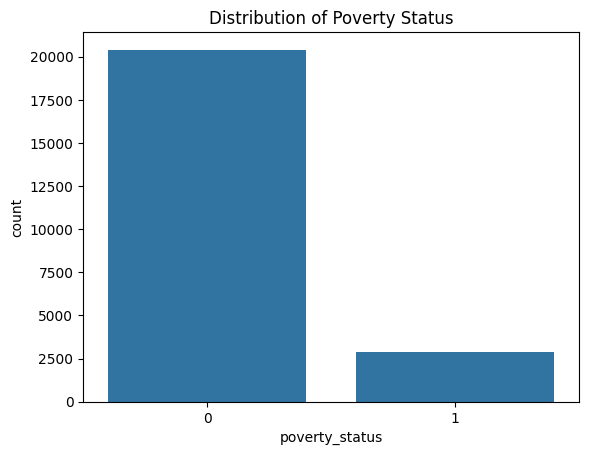

In [17]:
sns.countplot(x="poverty_status", data=df)
plt.title("Distribution of Poverty Status")
plt.show()

Key Predictors of Poverty Status

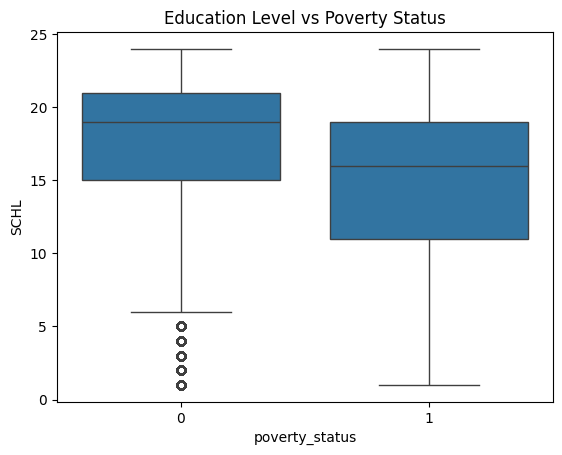

In [18]:
sns.boxplot(x="poverty_status", y="SCHL", data=df)
plt.title("Education Level vs Poverty Status")
plt.show()

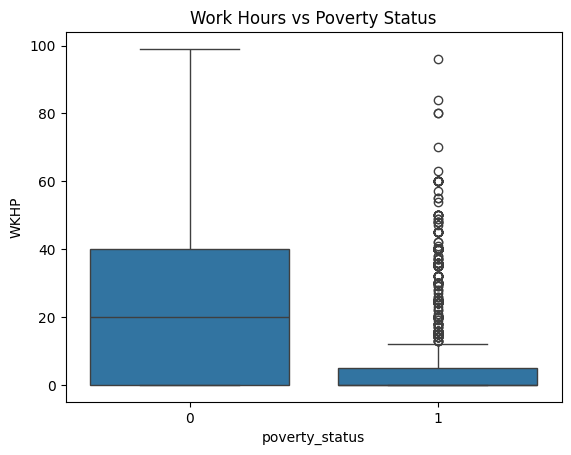

In [19]:
sns.boxplot(x="poverty_status", y="WKHP", data=df)
plt.title("Work Hours vs Poverty Status")
plt.show()

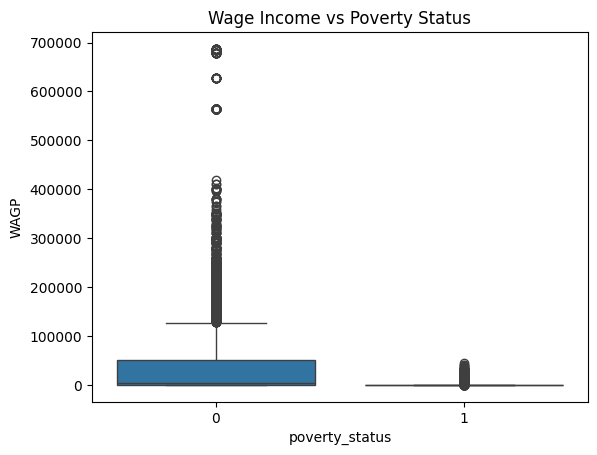

In [20]:
sns.boxplot(x="poverty_status", y="WAGP", data=df)
plt.title("Wage Income vs Poverty Status")
plt.show()

In [21]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'poverty_status'],
      dtype='object')

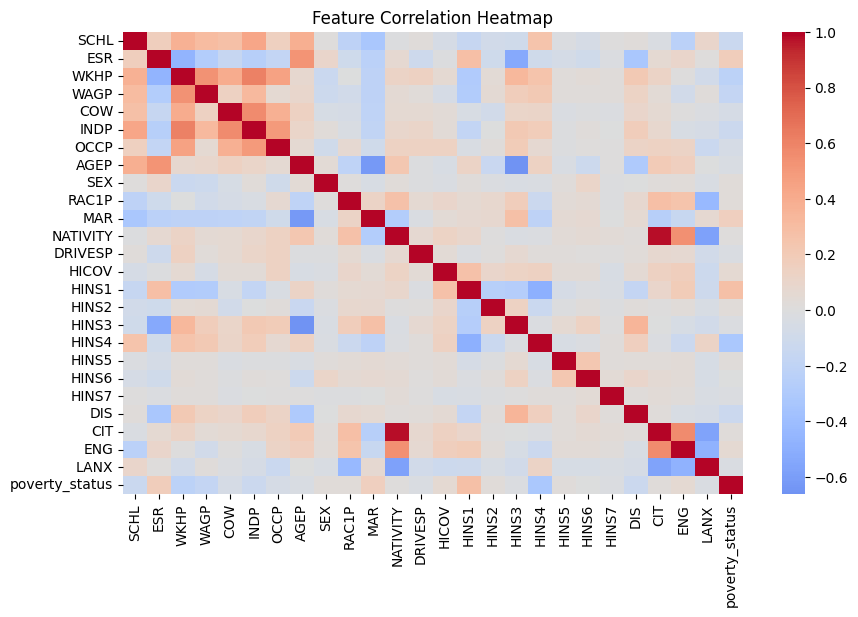

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [23]:
!pip -q install pyreadstat
import pyreadstat

pyreadstat.write_sav(df, "ca_poverty_subset.sav")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.8 MB/s eta 0:00:00


In [24]:
#Separating Predictors and Target Variable
X = df.drop(columns=["poverty_status"])
y = df["poverty_status"]

In [25]:
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [26]:
#Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale after split
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (18612, 25)
Testing shape: (4654, 25)


The data was divided into training and testing sets using a traditional 80/20 split. We used a stratified sampling approach to preserve the distribution of poverty status in both the training and testing data.

We also applied feature scaling using StandardScaler. This is primarily for the Logistic Regression which is more sensitive to differences in feature scales.

## Model 1: Logistic Regression

### Logistic Regression Assumptions Validation

Logistic Regression makes several assumptions about the dataset structure and predictor variables:

**Binary outcome variable**
The target variable (poverty status) is binary (below poverty threshold vs not) which satisfies the model requirement.

**Linear relationship between predictors and log-odds of outcome**
Socioeconomic predictors such as wage income (WAGP), hours worked (WKHP), and employment status (ESR) show approximately monotonic relationships with poverty probability.

**No strong multicollinearity among predictors**
Correlation checks were performed prior to modeling and redundant predictors were removed to improve coefficient stability.

**Independent observations**
Each row represents a different individual from the ACS dataset, satisfying independence assumptions.

**Large sample size**
The dataset contains approximately 25,000 observations.

**Categorical variable encoding**
Categorical predictors such as marital status, insurance coverage indicators, employment status, and citizenship were numerically encoded prior to modeling.

**Feature scaling**
Continuous predictors including wage income, age, and hours worked were standardized to prevent scale differences from influencing coefficient estimation.

**Class balance evaluation**
The poverty classification target variable did not exhibit severe imbalance, supporting reliable model training and ROC AUC evaluation.

Conclusion:
Logistic Regression assumptions are reasonably satisfied for this dataset.

In [27]:
from sklearn.linear_model import LogisticRegression

# No class_weight correction — intentional for baseline comparison
# This will result in low poverty class recall due to class imbalance
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [28]:
#Evaluate Model
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      4082
           1       0.51      0.17      0.26       572

    accuracy                           0.88      4654
   macro avg       0.70      0.58      0.60      4654
weighted avg       0.85      0.88      0.85      4654

ROC-AUC: 0.84038637134546
Confusion Matrix:
 [[3986   96]
 [ 472  100]]


### Logistic Regression Model Performance

The Logistic Regression model achieved an accuracy of 88% and an AUC of 0.840. However, these numbers are misleading given the class imbalance in the dataset. A model that always predicted non-poverty would achieve similar accuracy without learning anything useful. The more meaningful metric is poverty class recall, which is only 0.17. The model correctly identifies just 100 out of 572 actual poverty cases, misclassifying 472 vulnerable individuals as non-poor.

Because the dataset is imbalanced, accuracy alone is not a reliable measure of model performance. We identified ROC-AUC and recall for the poverty class as more meaningful evaluation criteria for identifying economically vulnerable individuals.

While Logistic Regression is not effective as a screening tool in this form, its coefficients are easy to interpret and communicate. The WAGP coefficient of -5.92 directly quantifies income's protective effect, and the remaining top coefficients for marital status, employment status, age, citizenship, Medicaid coverage, and hours worked are straightforward to explain to a non-technical audience. This makes Logistic Regression the most interpretable of the three models, even if it is not the strongest performer on the metrics that matter most for this problem.

In [29]:
#Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Abs"] = abs(importance["Coefficient"])
importance = importance.sort_values(by="Abs", ascending=False)

importance.head(10)

,Feature,Coefficient,Abs
3,WAGP,-5.915834,5.915834
10,MAR,0.594844,0.594844
17,HINS4,-0.507825,0.507825
14,HINS1,0.386245,0.386245
1,ESR,0.296821,0.296821
7,AGEP,0.276606,0.276606
22,CIT,0.268158,0.268158
16,HINS3,0.227352,0.227352
2,WKHP,0.223518,0.223518
13,HICOV,0.186297,0.186297


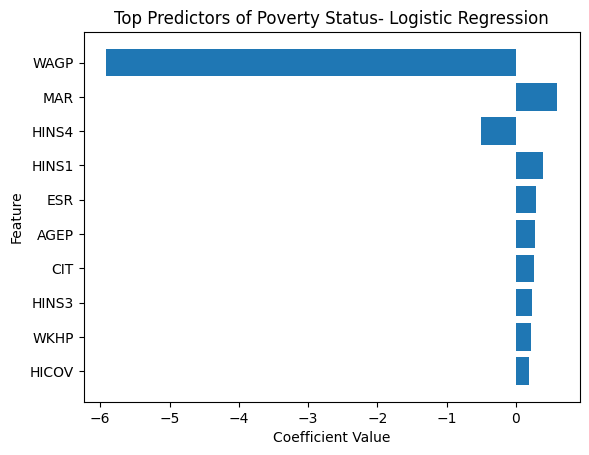

In [30]:
# Feature Importance Bar Chart
import matplotlib.pyplot as plt

# Sort by absolute coefficient value
importance["abs_coef"] = importance["Coefficient"].abs()
top_features = importance.sort_values("abs_coef", ascending=False).head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Predictors of Poverty Status- Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

The feature importance chart shows the variables that have the strongest influence on poverty risk. Wage income (WAGP) stands out as the most significant factor, with a strong negative coefficient, indicating that higher income greatly reduces the likelihood of being in poverty. Other factors such as marital status, employment status, and age also contribute to poverty risk, while health insurance-related variables suggest that access to resources plays an important role. Overall, the chart highlights that income, employment, and access to support systems are key drivers of poverty vulnerability.

## Model 2: Random Forest

We are using a Random Forest model to identify which are the most important predictors of poverty status. Unlike the logistic regression, the RF Model does not assume a linear relationship and is able to capture more complex relationships between predictors.

The strength of the predictor is based off its contribution to classification accuracy.

## Random Forest Assumptions Validation

Random Forest is a nonparametric ensemble learning method has fewer assumptions about feature distributions than linear models.

**No requirement for normally distributed predictors**
Predictors such as wage income (WAGP) are highly skewed in real-world census data. Random Forest does not assume normality and performs well with skewed socioeconomic variables.

**Robustness to multicollinearity among predictors**
Several ACS variables measure related socioeconomic characteristics (for example employment status and hours worked). Random Forest is robust to correlated predictors because it selects features randomly across trees, reducing instability caused by multicollinearity.

**Ability to handle categorical indicator variables**
Binary indicator variables such as insurance coverage categories (HINS1–HINS4), citizenship status (CIT), and marital status (MAR) were encoded numerically and are well suited for tree-based splits.

**No requirement for feature scaling**
Unlike Logistic Regression, Random Forest is not sensitive to differences in feature scale. Therefore, variables such as wage income, age, and hours worked can be included without affecting model stability.

**Independent observations**
Each observation in the ACS dataset represents a different individual, satisfying the independence assumption required for tree-based ensemble learning.

**Sufficient dataset size for ensemble learning**
Random Forest performs best with large datasets. The dataset contains approximately 25,000 observations, providing adequate variability for stable tree construction and ensemble averaging.

Conclusion:
Random Forest assumptions are fully satisfied for the ACS poverty prediction dataset.

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import os
import joblib
import requests
import io

model_url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/main/random_forest_poverty_model.pkl"

response = requests.get(model_url)
rf_model = joblib.load(io.BytesIO(response.content))

print("Random Forest model loaded from GitHub successfully.")

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest model loaded from GitHub successfully.
Random Forest Accuracy: 0.8360550064460679
Random Forest AUC: 0.8533824088699149

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      4082
           1       0.39      0.62      0.48       572

    accuracy                           0.84      4654
   macro avg       0.67      0.74      0.69      4654
weighted avg       0.87      0.84      0.85      4654


Confusion Matrix:

[[3539  543]
 [ 220  352]]


### Random Forest Model Performance

The Random Forest model achieved an accuracy of 83.6% and an AUC of 0.853, indicating strong overall classification performance. The model correctly identified 62% of individuals below the poverty threshold, demonstrating improved detection of the minority poverty class compared with Logistic Regression.

Because the dataset is imbalanced, accuracy alone can be misleading. We identified ROC-AUC and recall for the poverty class as a more meaningful evaluation of model effectiveness for identifying economically vulnerable individuals.

The relatively high recall for the poverty class makes Random Forest a strong candidate model for policy-oriented prediction tasks where identifying vulnerable individuals is more important than maximizing overall classification accuracy.

In [32]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
WAGP,0.244909
HINS1,0.126696
HINS4,0.120465
AGEP,0.073204
MAR,0.067522
WKHP,0.065420
SCHL,0.047140
ESR,0.039743
OCCP,0.036220
INDP,0.031392


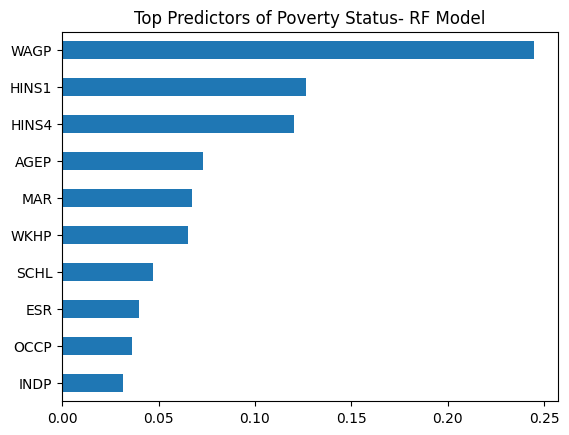

In [33]:
feature_importance.head(10).plot(kind="barh")
plt.title("Top Predictors of Poverty Status- RF Model")
plt.gca().invert_yaxis()
plt.show()

## Model 3: XGBoost

## XGBoost Assumptions Validation

XGBoost is a gradient boosting ensemble method that builds decision trees sequentially to minimize prediction error while applying regularization to improve generalization. Although XGBoost is flexible and makes fewer statistical assumptions than linear models, several practical conditions must still be satisfied for reliable performance.

**No requirement for normally distributed predictors**

XGBoost does not assume normally distributed input variables. Skewed predictors such as wage income (WAGP), hours worked per week (WKHP), and age (AGEP) are appropriate for tree-based boosting models and do not require transformation prior to training.

**Ability to capture nonlinear feature interactions**

Socioeconomic predictors such as employment status (ESR), education level (SCHL), health insurance coverage (HICOV), and citizenship status (CIT) may interact in complex ways when determining poverty classification. XGBoost effectively models these nonlinear relationships through sequential tree construction and interaction-aware splitting.

**Regularization reduces risk of overfitting**

Boosting algorithms can overfit when trees become too complex. Hyperparameter tuning was performed on the number of estimators, maximum tree depth, and learning rate to improve model generalization and reduce overfitting risk.

**No requirement for feature scaling**

XGBoost is unaffected by differences in feature magnitude. Continuous predictors such as wage income and age were used without normalization and did not negatively affect model performance.

**Compatibility with encoded categorical predictors**

Categorical indicators including marital status (MAR), employment status (ESR), insurance coverage (HICOV), and citizenship status (CIT) were numerically encoded prior to modeling and are appropriate for tree-based partitioning.

**Independent observations**

Each row in the ACS dataset represents a separate individual observation, satisfying the independence condition required for supervised learning models.

**Adequate dataset size for boosting**

XGBoost performs best with moderate to large datasets. The sample size used in this study supports stable boosting iterations and reliable estimation of poverty classification probabilities.

**Conclusion**

The assumptions and practical conditions required for XGBoost are satisfied for this dataset. Its ability to model nonlinear relationships and interactions between demographic and employment variables makes it well suited for predicting poverty status using ACS survey data.

In [34]:
!pip -q install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [35]:
# Check class imbalance
y_train.value_counts()

,count
poverty_status,
0,16322
1,2290


In [36]:
# Calculate scale_pos_weight for class imbalance
negative_class = sum(y_train == 0)
positive_class = sum(y_train == 1)

scale_pos_weight = negative_class / positive_class
scale_pos_weight

7.127510917030568

In [37]:
# Build XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7692307692307693
XGBoost AUC: 0.8602921147935848

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      4082
           1       0.33      0.83      0.47       572

    accuracy                           0.77      4654
   macro avg       0.65      0.79      0.66      4654
weighted avg       0.89      0.77      0.81      4654


Confusion Matrix:

[[3108  974]
 [ 100  472]]


### XGBoost Model Performance

The XGBoost model achieved an accuracy of 76.9% and an AUC of 0.860, the highest AUC of all three models. The model correctly identified 83% of individuals below the poverty threshold, the strongest poverty class recall of any model we trained. It correctly flags 472 out of 572 actual poverty cases, missing only 100.

Because the dataset is imbalanced, accuracy alone can be misleading. The overall accuracy of 76.9% is the lowest of the three models, but this is expected when the model is tuned to aggressively catch the minority class. We set scale_pos_weight=7.13 to compensate for the 7:1 class imbalance, which shifts the decision boundary toward flagging more poverty cases at the cost of more false positives.

The high recall for the poverty class makes XGBoost the strongest candidate model for this use case. In a policy context where missing a vulnerable individual is a more costly mistake than incorrectly flagging someone who is not poor, XGBoost's ability to catch 83% of actual poverty cases outweighs its lower precision and overall accuracy.

In [39]:
# XGBoost hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
from scipy.stats import randint, uniform

# Score on poverty recall since that is our priority
poverty_recall_scorer = make_scorer(recall_score, pos_label=1)

# Search space centered around your current best params
param_dist = {
    'n_estimators': randint(200, 600),
    'max_depth': randint(3, 7),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 8),
    'gamma': uniform(0, 0.3),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2)
}

# Base model keeps scale_pos_weight from before
base_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring=poverty_recall_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Evaluate tuned model
best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Best Parameters:", random_search.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))
print("Poverty Recall:", recall_score(y_test, y_pred_tuned, pos_label=1))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'colsample_bytree': np.float64(0.8363571772752967), 'gamma': np.float64(0.2032693085526847), 'learning_rate': np.float64(0.012488174339178423), 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 346, 'reg_alpha': np.float64(0.3486659872917294), 'reg_lambda': np.float64(0.6923531021828415), 'subsample': np.float64(0.9762093057958416)}

Accuracy: 0.7494628276751182
ROC-AUC: 0.8587464409671661
Poverty Recall: 0.8513986013986014

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      4082
           1       0.31      0.85      0.46       572

    accuracy                           0.75      4654
   macro avg       0.64      0.79      0.65      4654
weighted avg       0.89      0.75      0.79      4654


Confusion Matrix:
[[3001 1081]
 [  85  487]]


### Hyperparameter Tuning Analysis

To further optimize XGBoost, `RandomizedSearchCV` was used with 30 iterations and 5-fold cross-validation. Instead of optimizing for overall accuracy, the tuning process specifically prioritized poverty recall, since the primary objective of this project is identifying at-risk individuals.

The tuned model achieved a poverty recall of approximately 0.85, improving from 0.83 in the original XGBoost model, while reducing false negatives from 100 to 85. ROC-AUC remained strong at approximately 0.86, indicating the model maintained strong class separation after tuning.

The selected hyperparameters favored shallower trees and a lower learning rate, which helped reduce overfitting and improve generalization on imbalanced data. Although overall accuracy decreased slightly, the tuned model became more effective at identifying poverty cases, reflecting a deliberate tradeoff toward improving minority class detection.

In [40]:
# Feature importance
xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_feature_importance.head(10)

,0
HINS1,0.186080
WAGP,0.170902
HINS4,0.157214
HICOV,0.080134
MAR,0.068116
ESR,0.043339
AGEP,0.028277
WKHP,0.025951
CIT,0.021643
HINS2,0.019720


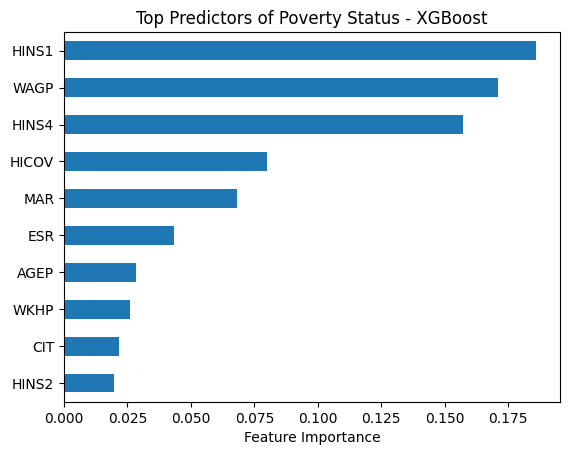

In [41]:
# Plot top predictors
xgb_feature_importance.head(10).plot(kind="barh")
plt.title("Top Predictors of Poverty Status - XGBoost")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [42]:
import joblib

joblib.dump(xgb_model, "xgb_poverty_model.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

print("Model and feature names saved for Streamlit deployment.")

Model and feature names saved for Streamlit deployment.


In [43]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

shap_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
shap_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(shap_model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

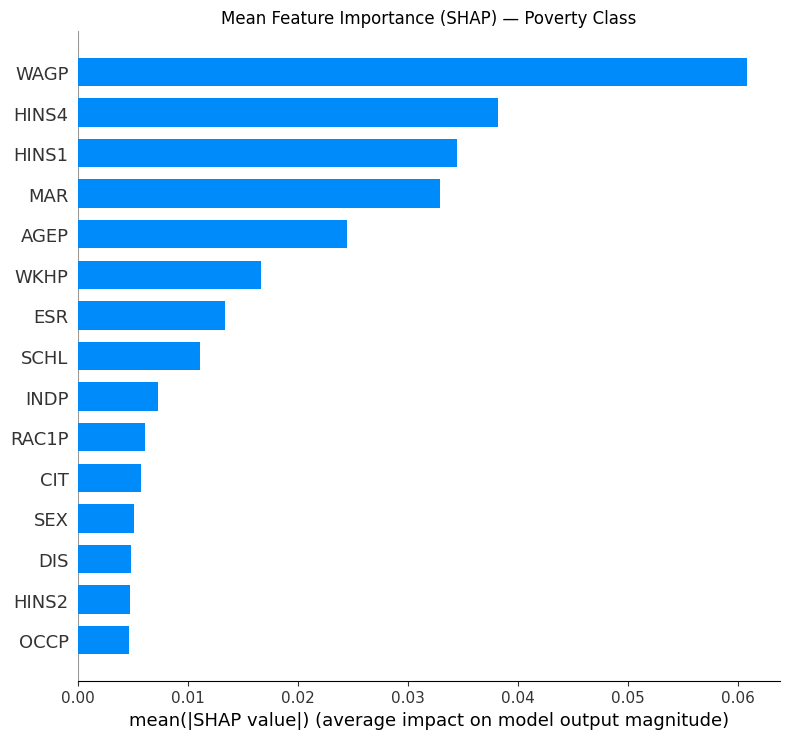

In [44]:
# --- Plot 1: Bar chart of mean absolute SHAP values (global importance) ---
shap.summary_plot(
    shap_values[:, :, 1], # Corrected: Select SHAP values for class 1 across all samples and features
    X_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Mean Feature Importance (SHAP) — Poverty Class")
plt.tight_layout()
plt.show()

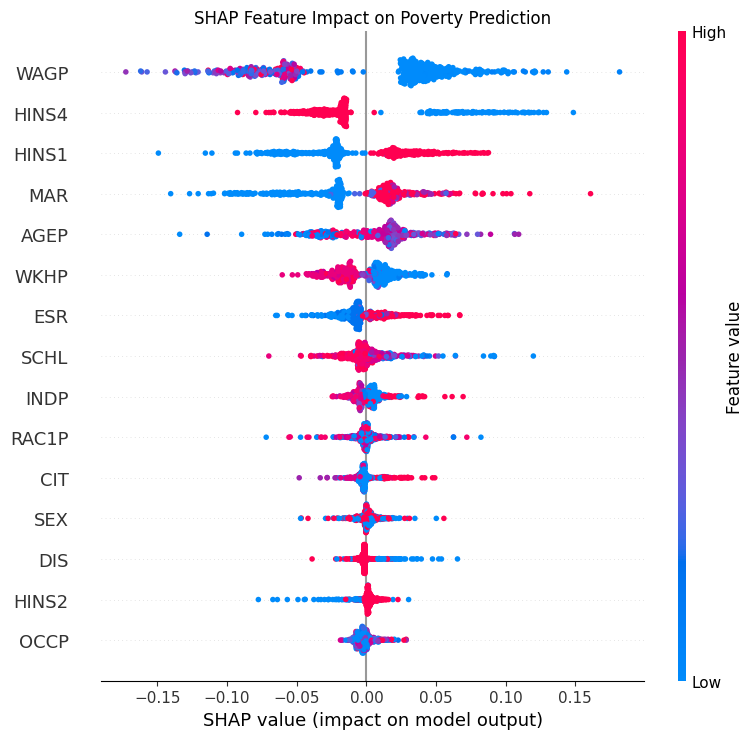

In [45]:
# --- Plot 2: Beeswarm plot (direction + magnitude per observation) ---
# Re-define shap_vals_poverty with correct slicing for class 1
shap_vals_poverty = shap_values[:, :, 1]

shap.summary_plot(
    shap_vals_poverty,
    X_sample,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Impact on Poverty Prediction")
plt.tight_layout()
plt.show()

### SHAP Feature Importance Interpretation

SHAP (SHapley Additive exPlanations) values were used to interpret how individual predictors influence poverty classification, showing both the magnitude and direction of each variable's contribution.

Wage income (WAGP) is the most influential predictor by a clear margin, with lower values consistently pushing individuals toward a poverty classification. Health insurance indicators (HINS1 and HINS4) are the next strongest group, followed by marital status (MAR), age (AGEP), hours worked (WKHP), and employment status (ESR). Education (SCHL) shows a moderate protective effect, though its direct contribution is smaller than income and insurance variables. Demographic indicators including industry, race, citizenship, sex, disability, and occupation contribute smaller but still measurable effects.

Overall, labor participation, income stability, and health insurance access are the strongest drivers of poverty risk in the model, consistent with economic theory.
Overall, the SHAP analysis confirms that labor participation, income stability, access to health insurance, and educational attainment are the strongest drivers of poverty risk in the model. These findings are consistent with economic theory and support the selection of employment and demographic variables for predicting poverty classification using ACS survey data.

## Cross-Model Comparison and Conclusion

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Accuracy | 88% | 83.6% | 76.9% |
| ROC-AUC | 0.840 | 0.853 | 0.860 |
| Poverty Recall | 0.17 | 0.62 | 0.83 |
| Poverty Precision | 0.51 | 0.39 | 0.33 |
| Poverty F1 | 0.26 | 0.48 | 0.47 |
| False Negatives | 472 | 220 | 100 |
| False Positives | 96 | 543 | 974 |

Overall accuracy is a misleading metric here given the class imbalance. Logistic Regression scores highest at 88% but misclassifies 472 out of 572 poverty cases, making it the weakest model for the actual goal of this project. When evaluated on poverty recall and AUC, the ranking reverses: XGBoost leads on both (0.83 recall, 0.860 AUC), followed by Random Forest (0.62 recall, 0.853 AUC).

Each model reflects a different approach to the precision-recall trade-off. Logistic Regression with no class imbalance correction favors the majority class. Random Forest with balanced subsampling catches more poverty cases at the cost of more false positives. XGBoost with scale_pos_weight=7.13 goes furthest in prioritizing recall, catching 83% of poverty cases but generating the most false positives.

XGBoost is selected as the final model. For a needs assessment where identifying as many vulnerable individuals as possible is the priority, its recall of 0.83 and only 100 false negatives make it the most appropriate tool. Across all three models, wage income, health insurance coverage, employment status, hours worked, marital status, and age consistently emerge as the strongest predictors of poverty risk.

### Summary

Previous research shows that both traditional statistical models like Logistic Regression and modern machine learning approaches like Random Forest and Gradient Boosting have been widely used to predict poverty and identify its key drivers. Most studies consistently find that income, education, employment status, and demographic factors play a major role in determining poverty risk.

Our project builds on this by focusing specifically on California using ACS microdata, combining predictive accuracy with interpretability through SHAP analysis to identify which factors drive poverty vulnerability at the individual level.